In [2]:
from qiskit import *
from qiskit_aer import AerSimulator, StatevectorSimulator
import numpy as np
from qiskit import QuantumCircuit
from qiskit.circuit import ParameterVector
import matplotlib.pyplot as plt

# Data generation

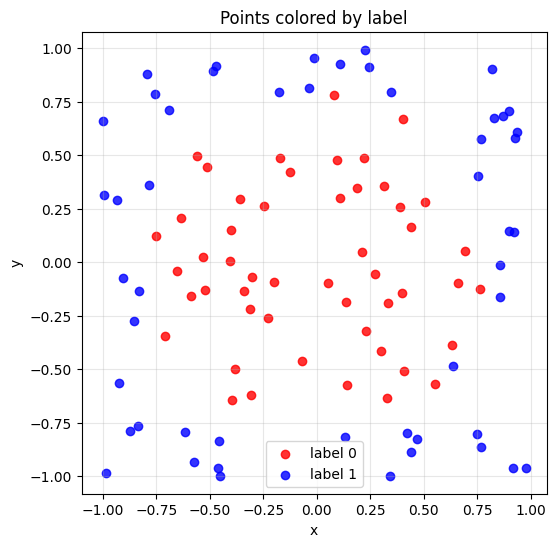

points in label 0: 50
points in label 1: 50


In [3]:
n = 100
points = np.random.rand(n, 2) * 2 - 1
labels = [0 if x**2 + y**2 < 2/np.pi else 1 for x, y in points]


import matplotlib.pyplot as plt

arr = np.array(points)
lbl = np.array(labels)

plt.figure(figsize=(6, 6))
plt.scatter(arr[lbl == 0, 0], arr[lbl == 0, 1], c="red", label="label 0", alpha=0.8)
plt.scatter(arr[lbl == 1, 0], arr[lbl == 1, 1], c="blue", label="label 1", alpha=0.8)

plt.xlabel("x")
plt.ylabel("y")
plt.title("Points colored by label")
plt.axis("equal")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print("points in label 0:", np.sum(lbl == 0))
print("points in label 1:", np.sum(lbl == 1))

In [4]:

test_size = 0.2
rng = np.random.default_rng(42)

indices = rng.permutation(len(arr))
split_idx = int(len(arr) * (1 - test_size))

train_idx, test_idx = indices[:split_idx], indices[split_idx:]

X_train, X_test = arr[train_idx], arr[test_idx]
y_train, y_test = lbl[train_idx], lbl[test_idx]

print("X_train:", X_train.shape, "y_train:", y_train.shape)
print("X_test :", X_test.shape, "y_test :", y_test.shape)

X_train: (80, 2) y_train: (80,)
X_test : (20, 2) y_test : (20,)


In [5]:
def U(q, theta, omega, x, qubit):
    wx = np.multiply(np.asarray(omega), np.asarray(x))  # Hadamard product
    q.rx(theta[0] + wx[0], qubit)
    q.rz(theta[1] + wx[1], qubit)

In [6]:
rc = 3

def create_circuit(x, theta, omega):
    qc = QuantumCircuit(1)
    for i in range(rc):
        U(qc, theta[i], omega[i], x, 0)
    qc.measure_all()
    qc.draw()
    return qc


In [7]:
theta = [[1,1] for _ in range(rc)]
omega = [[1,1] for _ in range(rc)]
qc =create_circuit(X_train[0], theta, omega)
qc.draw()

┌─────────────┐┌────────────┐┌─────────────┐┌────────────┐»
     q: ┤ Rx(0.24471) ├┤ Rz(1.7875) ├┤ Rx(0.24471) ├┤ Rz(1.7875) ├»
        └─────────────┘└────────────┘└─────────────┘└────────────┘»
meas: 1/══════════════════════════════════════════════════════════»
                                                                  »
«        ┌─────────────┐┌────────────┐ ░ ┌─┐
«     q: ┤ Rx(0.24471) ├┤ Rz(1.7875) ├─░─┤M├
«        └─────────────┘└────────────┘ ░ └╥┘
«meas: 1/═════════════════════════════════╩═
«                                         0

In [8]:
sim = AerSimulator()

def compute_fidelity(circuit, target_bitstring, shots=1024):
    """
    Calcule la fidélité expérimentale basée sur le shot count.
    """
    compiled_qc = transpile(circuit, sim)
    
    result = sim.run(compiled_qc, shots=shots).result()
    
    # Get counts and convert to probabilities
    counts = result.get_counts()
    
    # Convert counts to probabilities
    total_shots = sum(counts.values())
    probabilities = {bitstring: count/total_shots for bitstring, count in counts.items()}
    
    # Get fidelity for target bitstring
    fidelity = probabilities.get(target_bitstring, 0)
    
    # Return cost (1 - fidelity)
    return fidelity

def cost_function(theta, omega, X_train, y_train):
    total_cost = 0
    for x, y in zip(X_train, y_train):
        qc = create_circuit(x, theta, omega)
        target_bitstring = '0' if y == 0 else '1'
        fidelity = compute_fidelity(qc, target_bitstring)
        total_cost += (1 - fidelity)
    return total_cost / len(X_train)



In [ ]:
import numpy as np
from scipy.optimize import minimize



def unpack_params(params, rc):
    split = 2 * rc
    theta = params[:split].reshape(rc, 2)
    omega = params[split:].reshape(rc, 2)
    return theta, omega

def objective(params, X_train, y_train, rc):
    theta, omega = unpack_params(params, rc)
    return cost_function(theta, omega, X_train, y_train)



def optimize_parameters(X_train, y_train, rc, maxiter=80, seed=42):
    rng = np.random.default_rng(seed)
    init = rng.uniform(-np.pi, np.pi, size=4 * rc)  # theta(rcx2) + omega(rcx2)

    res = minimize(
        objective,
        init,
        args=(X_train, y_train, rc),
        method="COBYLA",          # derivative-free, good for shot noise
        options={"maxiter": maxiter}
    )
    theta_opt, omega_opt = unpack_params(res.x, rc)
    return theta_opt, omega_opt, res

In [ ]:
def predict_one(x, theta, omega, shots=512):
    qc = create_circuit(x, theta, omega)
    compiled_qc = transpile(qc, sim)
    counts = sim.run(compiled_qc, shots=shots).result().get_counts()
    return 0 if counts.get("0", 0) >= counts.get("1", 0) else 1

def evaluate_precision(X, y, theta, omega, positive_label=1, shots=512):
    y_pred = np.array([predict_one(x, theta, omega, shots=shots) for x in X])
    tp = np.sum((y_pred == positive_label) & (y == positive_label))
    fp = np.sum((y_pred == positive_label) & (y != positive_label))
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0.0
    return precision

# --- train + test ---
theta_opt, omega_opt, res = optimize_parameters(X_train, y_train, rc, maxiter=80)
precision_test = evaluate_precision(X_test, y_test, theta_opt, omega_opt)

print("Final train cost:", res.fun)
print("Test precision:", precision_test)